In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as ss

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [12]:
datap = pd.read_csv('data.txt', sep=',')

In [13]:
datap.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [15]:
datap.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

C:\Users\Alumno\AppData\Local\Temp\ipykernel_31052\283231413.py:1: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


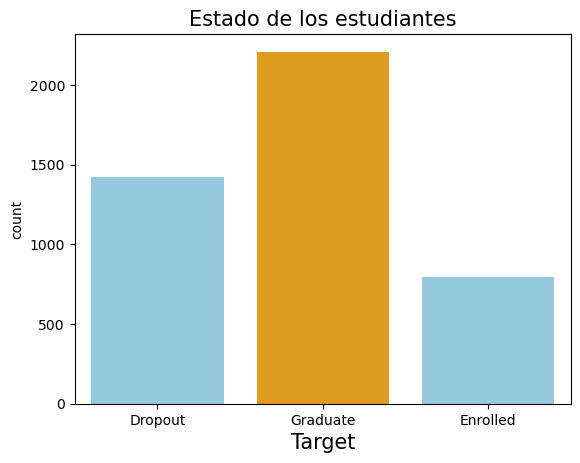

In [18]:
sns.countplot(
    data = datap,
    x='Target',
    hue= 'Target',
    palette=['skyblue', 'orange'],
    legend=False
)

plt.xlabel('Target', fontsize=15)
plt.title('Estado de los estudiantes', fontsize=15)
plt.show()

In [23]:
x = datap.iloc[:,[6,19]].values
y = datap.iloc[:,-1]

In [24]:
x[0:5]

array([[122.,  20.],
       [160.,  19.],
       [122.,  19.],
       [122.,  20.],
       [100.,  45.]])

In [25]:
y[0:5]

0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object

In [26]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0) 

In [27]:
X_train[0:5]

array([[140. ,  34. ],
       [140. ,  20. ],
       [133.1,  25. ],
       [135. ,  20. ],
       [126. ,  19. ]])

In [28]:
X_test[0:5]

array([[133.,  18.],
       [144.,  23.],
       [140.,  19.],
       [136.,  19.],
       [116.,  22.]])

In [29]:
X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

In [30]:
X_train[0:5]

array([[ 0.55764528,  1.40217744],
       [ 0.55764528, -0.43415908],
       [ 0.03687537,  0.22167539],
       [ 0.18027578, -0.43415908],
       [-0.49898933, -0.56532598]])

In [31]:
X_test[0:5]

array([[ 0.02931281, -0.68406361],
       [ 0.87986496, -0.01155051],
       [ 0.57057327, -0.54956099],
       [ 0.26128158, -0.54956099],
       [-1.28517687, -0.14605313]])

In [32]:
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=5),x, y, cv=5)

In [33]:
print (cv_scores)

[0.48248588 0.47231638 0.48361582 0.51186441 0.47511312]


In [34]:
print("CV_SCORES MEAN:{}".format(np.mean(cv_scores)))

CV_SCORES MEAN:0.48507912160953043


In [35]:
k_range = range(1,31)
k_scores = []

In [36]:
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x, y , cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

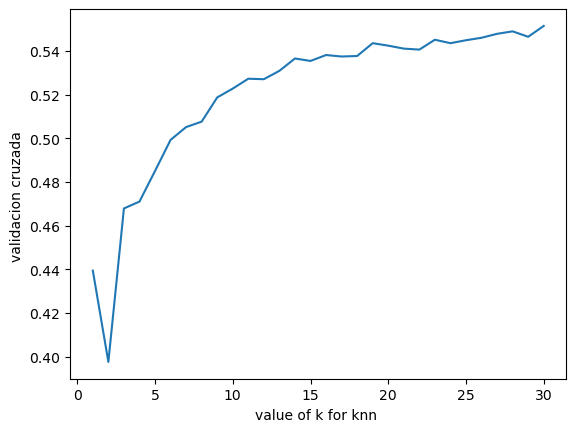

In [37]:
plt.plot(k_range, k_scores)
plt.xlabel('value of k for knn ')
plt.ylabel('validacion cruzada ')
plt.show()

In [38]:
tune = pd.concat([pd.DataFrame(k_range),pd.DataFrame(k_scores)],axis=1)
tune.columns = ['k_range', 'k_scores']
tune

,k_range,k_scores
0,1,0.439424
1,2,0.397600
2,3,0.467904
3,4,0.471064
4,5,0.485079
5,6,0.499319
6,7,0.505197
7,8,0.507684
8,9,0.518764
9,10,0.522830


In [39]:
classifier = KNeighborsClassifier(n_neighbors=8).fit(X_train, y_train)

In [40]:
y_pred = classifier.predict(X_test)

In [41]:
y_pred[0:5]

array(['Dropout', 'Enrolled', 'Graduate', 'Graduate', 'Graduate'],
      dtype=object)

In [42]:
y_test[0:5]

220     Graduate
1332     Dropout
3448    Graduate
2905    Graduate
841     Enrolled
Name: Target, dtype: object

In [43]:
confusion_matrix(y_test, y_pred)

array([[149,  15, 120],
       [ 58,   8,  85],
       [120,  20, 310]])

Matriz de confusion sin normalidad
[[149  15 120]
 [ 58   8  85]
 [120  20 310]]
Matriz de confusión normalizada
[[0.52464789 0.0528169  0.42253521]
 [0.38410596 0.05298013 0.56291391]
 [0.26666667 0.04444444 0.68888889]]


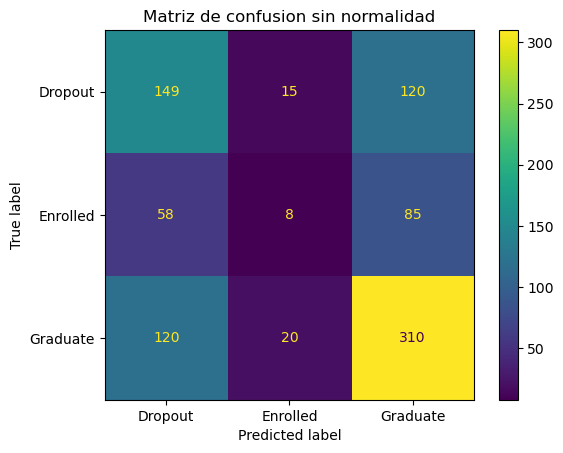

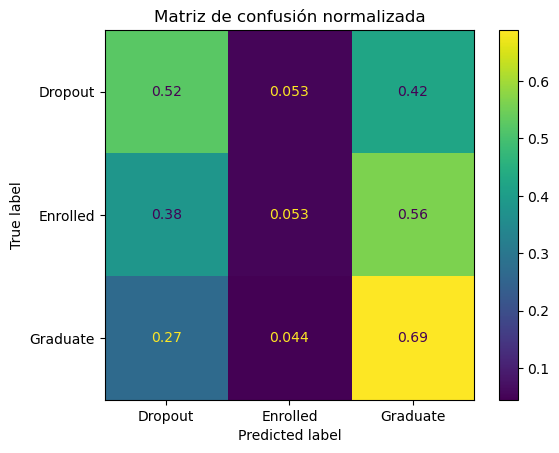

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
titles_options=[
    ("Matriz de confusion sin normalidad", None),
    ("Matriz de confusión normalizada","true")
]

for title, normalize in titles_options:
    disp =ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        normalize = normalize
    )
    disp.ax_.set_title(title)
    print(title)
    print(disp.confusion_matrix)
plt.show()

In [45]:
y_pred_prob = classifier.predict_proba(X_test)
y_pred_prob[0:5]

array([[0.5  , 0.   , 0.5  ],
       [0.   , 0.5  , 0.5  ],
       [0.25 , 0.   , 0.75 ],
       [0.125, 0.25 , 0.625],
       [0.25 , 0.125, 0.625]])

In [46]:
y_pred_prob[0:5,1]

array([0.   , 0.5  , 0.   , 0.25 , 0.125])

In [53]:
from sklearn.preprocessing import label_binarize

In [54]:
print(classifier.classes_)

['Dropout' 'Enrolled' 'Graduate']


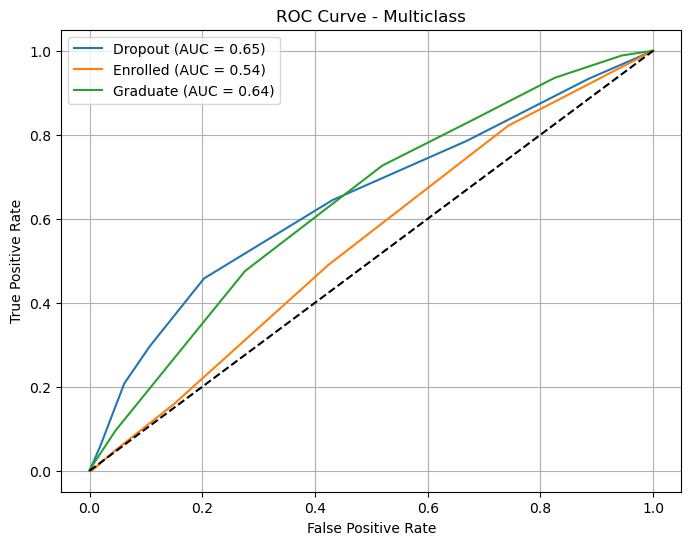

In [55]:
y_test_bin = label_binarize(y_test, classes=classifier.classes_)

# Probabilidades predichas
y_pred_prob = classifier.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classifier.classes_):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_name} (AUC = {roc_auc:.2f})'
    )

# Línea de referencia
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multiclass')
plt.legend()
plt.grid()
plt.show()

In [63]:
dataf = pd.concat([pd.DataFrame(X_test),pd.DataFrame(y_test),pd.DataFrame(y_pred),pd.DataFrame(y_pred_prob)],axis=1)

In [61]:
dataf.head()

,0,1,Target,0,0,1,2
0,0.029313,-0.684064,NaN,Dropout,0.500,0.000,0.500
1,0.879865,-0.011551,Graduate,Enrolled,0.000,0.500,0.500
2,0.570573,-0.549561,NaN,Graduate,0.250,0.000,0.750
3,0.261282,-0.549561,NaN,Graduate,0.125,0.250,0.625
4,-1.285177,-0.146053,NaN,Graduate,0.250,0.125,0.625


In [65]:
from sklearn.naive_bayes import GaussianNB  # el modelo naive bayes 

In [66]:
classifier = GaussianNB().fit(X_train, y_train)

In [67]:
confusion_matrix(y_test, y_pred)

array([[149,  15, 120],
       [ 58,   8,  85],
       [120,  20, 310]])

Matriz de Confusión, sin normalización
[[ 71   0 213]
 [ 12   0 139]
 [ 42   0 408]]
Matriz de Confusión Normalizada
[[0.25       0.         0.75      ]
 [0.0794702  0.         0.9205298 ]
 [0.09333333 0.         0.90666667]]


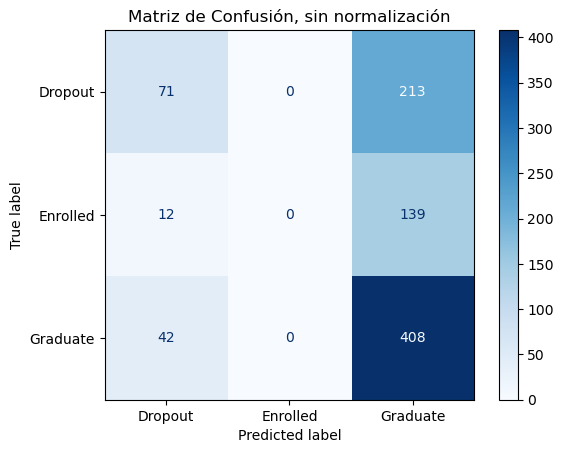

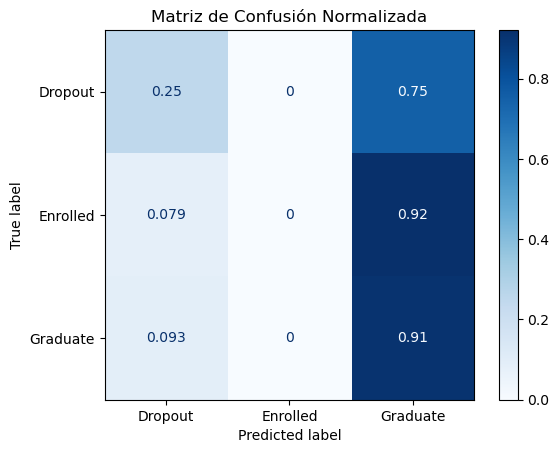

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
titles_options = [
  ("Matriz de Confusión, sin normalización", None),
  ("Matriz de Confusión Normalizada", "true")
]

for title, normalize in titles_options:
  disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    classifier.predict(X_test),
    cmap=plt.cm.Blues,
    normalize=normalize

  )
  disp.ax_.set_title(title)
  print(title)
  print(disp.confusion_matrix)
plt.show()

In [69]:
y_pred_prob = classifier.predict_proba(X_test)

In [73]:
y_test_bin = label_binarize(y_test, classes=classifier.classes_)

y_pred_prob = classifier.predict_proba(X_test)

false_positive_rate = {}
true_positive_rate = {}
roc_auc = {}

for i, clase in enumerate(classifier.classes_):
    false_positive_rate[i], true_positive_rate[i], _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        false_positive_rate[i],
        true_positive_rate[i]
    )

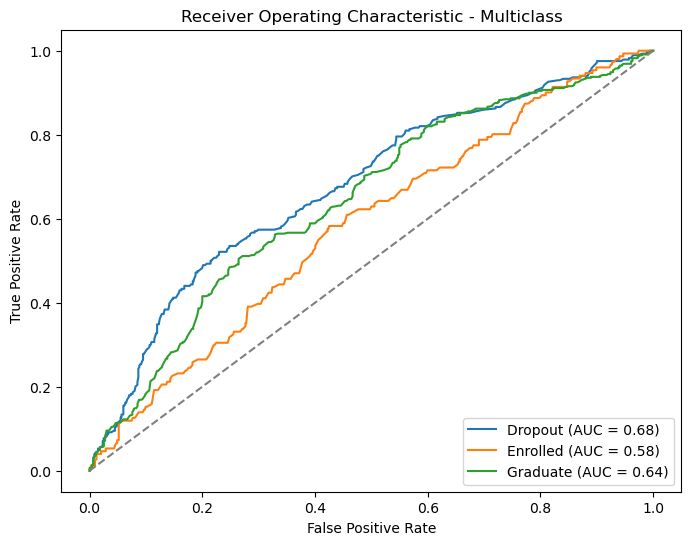

In [74]:
plt.figure(figsize=(8, 6))

for i, clase in enumerate(classifier.classes_):
    plt.plot(
        false_positive_rate[i],
        true_positive_rate[i],
        label='{} (AUC = {:.2f})'.format(clase, roc_auc[i])
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('Receiver Operating Characteristic - Multiclass')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.axis('tight')

plt.show()